In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data= pd.read_csv("C:\\Users\\lenovo\\Downloads\\Mall_Customers.csv")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
data.rename(columns = {'Annual Income (k$)' : 'Annual Income','Spending Score (1-100)':'Spending Score'}, inplace= True)
data.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


c:\Users\lenovo\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


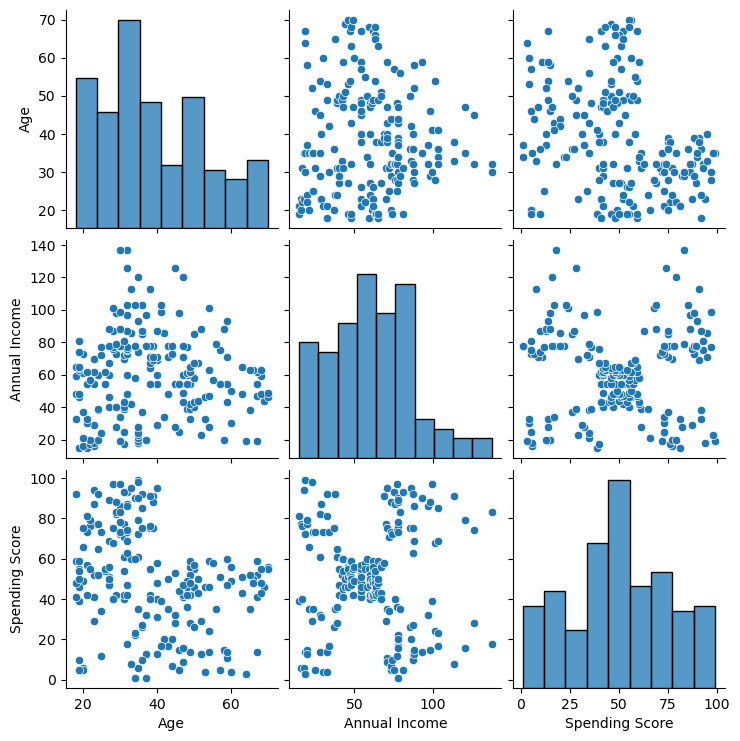

In [6]:
sns.pairplot(data[['Age','Annual Income','Spending Score']])
plt.show()

In [7]:

cols = ['Age','Annual Income','Spending Score']
Q1 = data[cols].quantile(0.25)
Q3 = data[cols].quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = data[((data[cols] < (Q1 - 1.5 * IQR)) | (data[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Number of outliers detected (IQR):", outliers_iqr.shape[0])
print(outliers_iqr)


Number of outliers detected (IQR): 2
     CustomerID Gender  Age  Annual Income  Spending Score
198         199   Male   32            137              18
199         200   Male   30            137              83


In [8]:
data = data.drop(outliers_iqr.index)
data.reset_index(drop=True, inplace=True)

In [9]:
data.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


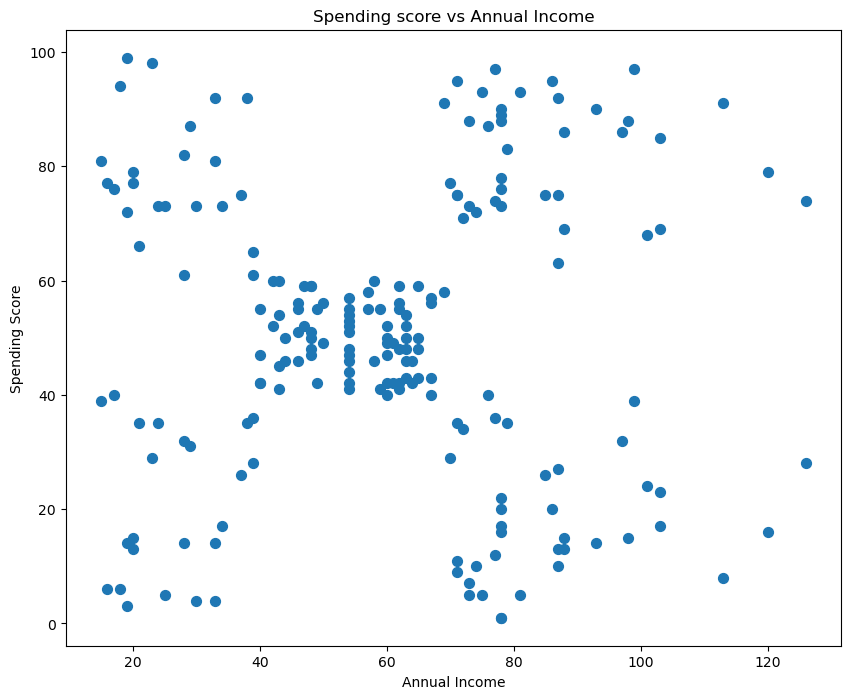

In [10]:
plt.figure(figsize = (10,8))
plt.scatter(data['Annual Income'],data['Spending Score'],s=50)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Spending score vs Annual Income')
plt.show()


In [11]:
from sklearn.preprocessing import StandardScaler

X = data[['Age','Annual Income','Spending Score']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled_df.head())


        Age  Annual Income  Spending Score
0 -1.425414      -1.779171       -0.435989
1 -1.282367      -1.779171        1.199413
2 -1.353890      -1.739447       -1.720949
3 -1.139319      -1.739447        1.043661
4 -0.567131      -1.699723       -0.397051


In [12]:
from sklearn.cluster import KMeans

In [24]:
x= X_scaled_df[['Annual Income','Spending Score']]
wcss=[]

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init ='k-means++',max_iter=300,n_init=10,random_state =0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

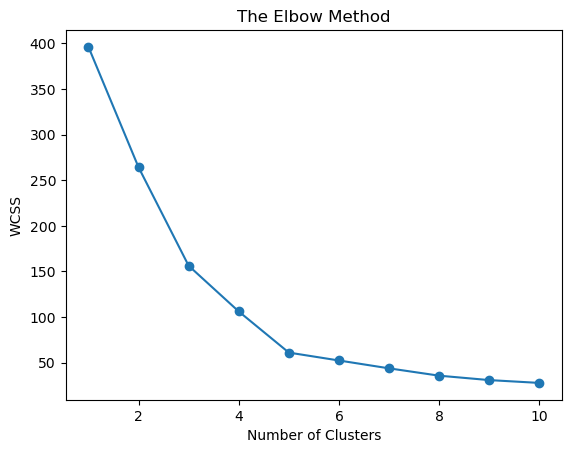

In [25]:
plt.plot(range(1,11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [26]:
kmeans = KMeans(n_clusters=5,init ='k-means++',max_iter=300,n_init=10,random_state =0)
y_kmean =kmeans.fit_predict(x)

In [27]:
X_scaled_df['cluster']= y_kmean
X_scaled_df.head()

,Age,Annual Income,Spending Score,cluster
0,-1.425414,-1.779171,-0.435989,3
1,-1.282367,-1.779171,1.199413,2
2,-1.353890,-1.739447,-1.720949,3
3,-1.139319,-1.739447,1.043661,2
4,-0.567131,-1.699723,-0.397051,3


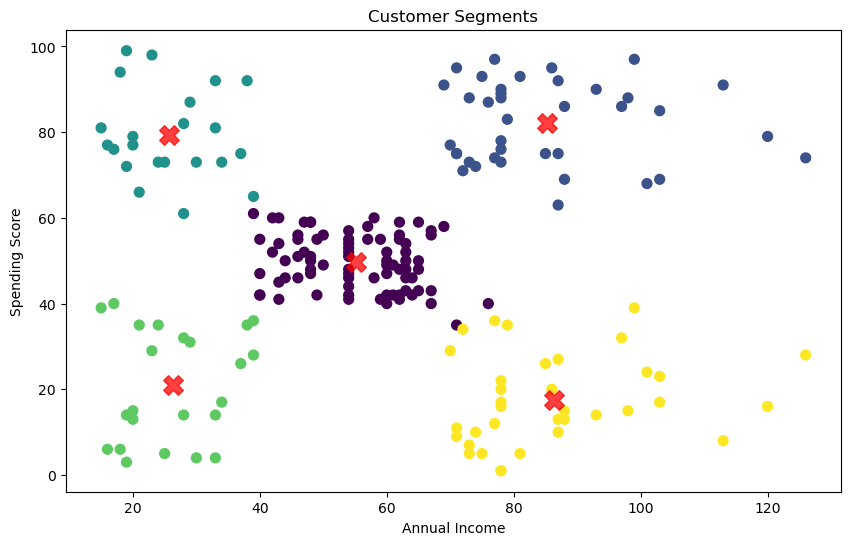

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=y_kmean, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1],c='red', s=200, alpha=0.75, marker='X')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments')
plt.show()


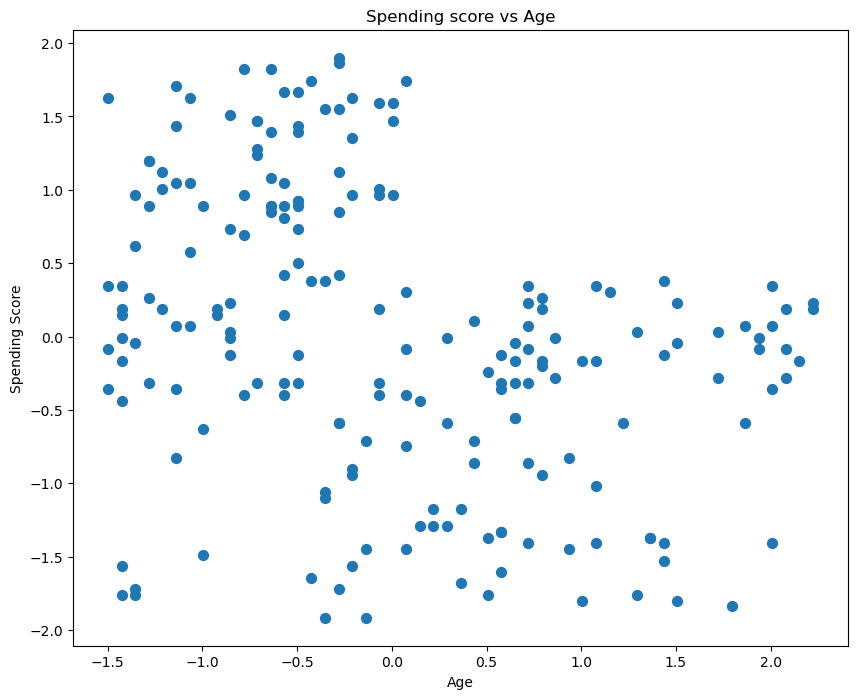

In [28]:
plt.figure(figsize = (10,8))
plt.scatter(X_scaled_df['Age'],X_scaled_df['Spending Score'],s=50)
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.title('Spending score vs Age')
plt.show()


In [29]:
x= X_scaled_df[['Age','Spending Score']]
wcss=[]

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init ='k-means++',max_iter=300,n_init=10,random_state =0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

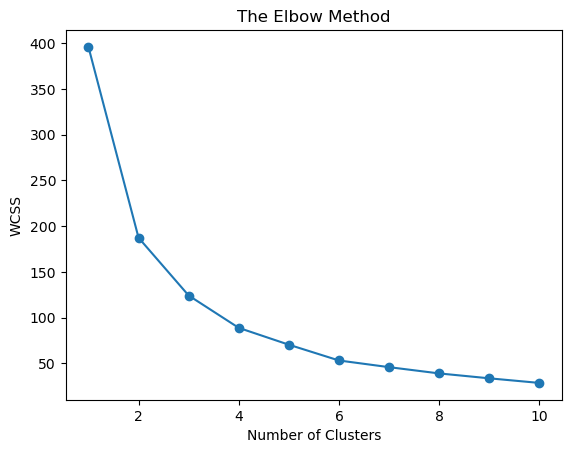

In [30]:
plt.plot(range(1,11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [21]:
kmeans = KMeans(n_clusters=4,init ='k-means++',max_iter=300,n_init=10,random_state =0)
y_kmean =kmeans.fit_predict(x)

In [31]:
X_scaled_df['cluster Age']= y_kmean
X_scaled_df.head()

,Age,Annual Income,Spending Score,cluster,cluster Age
0,-1.425414,-1.779171,-0.435989,3,3
1,-1.282367,-1.779171,1.199413,2,2
2,-1.353890,-1.739447,-1.720949,3,3
3,-1.139319,-1.739447,1.043661,2,2
4,-0.567131,-1.699723,-0.397051,3,3


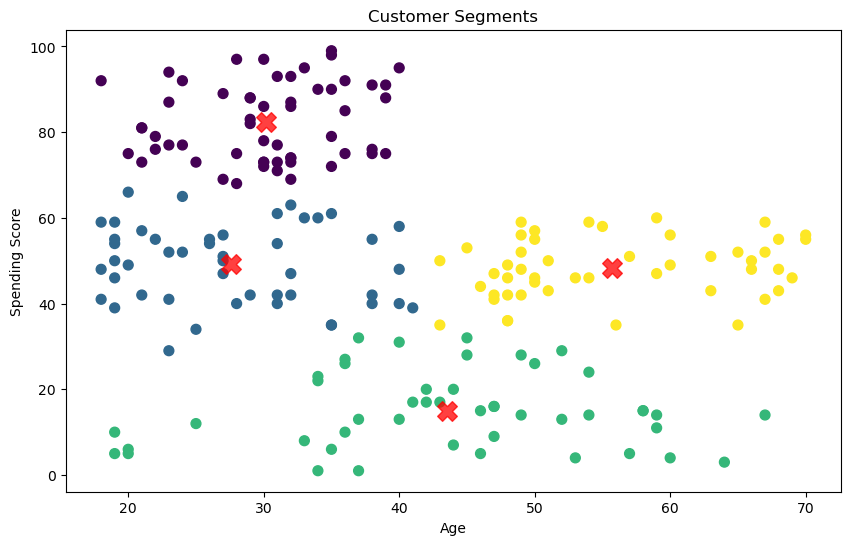

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=y_kmean, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.title('Customer Segments')
plt.show()
